In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# 데이터 불러오기
df = pd.read_csv('./data/lending_club_preprocessed3.csv')

In [3]:
# 통계검증용 데이터 프레임 생성
stat = df.copy()

In [4]:
# 생성후 Drop / "annual_inc", "revol_bal","installment" 은 개인 판단으로 고고 저는 뺄예정 
stat = stat.drop(columns=["issue_d", "earliest_cr_line", "annual_inc", "revol_bal","installment"])

In [5]:
# 1- 모델을 위해 최적화된 변수 선택 
use_col = [
    # ── 타겟 ──
    "target",                        # 부도 여부 (0/1)
    # ── 대출 기본 정보 ──
    "loan_amnt",                     # 대출 금액
    "term",                          # 기간 (36/60개월)
    "int_rate",                      # 이자율
    "sub_grade",                     # 등급 세분류 (A1~G5)                 # 월 상환액 ($)
    "purpose",                       # 대출 목적
    "issue_year",                    # 대출 실행 연도
    # ── 차입자 정보 ──
    "emp_length",                    # 근속 연수
    "home_ownership",                # 주거 형태
    # ── 부채 관련 지표 ──
    "dti",                           # 부채 대비 소득 비율
    "fico_mid",                      # FICO 점수 평균
    "pub_rec",                       # 공공 부정 기록 건수
    # ── 계좌 잔액 / 한도 ──
    "avg_cur_bal",                   # 전체 계좌 평균 잔액 ($)
    "revol_util",                    # 리볼빙 이용률 (%)
    "total_rev_hi_lim",              # 전체 리볼빙 신용 한도 ($)
    "bc_open_to_buy",                # 뱅크카드 잔여 한도 ($)
    "total_bc_limit",                # 뱅크카드 총 한도 ($)
    "tot_hi_cred_lim",               # 전체 계좌 신용한도 합계 ($)
    # ── 계좌 수량 ──
    "num_actv_bc_tl",                # 활성 뱅크카드 수
    "num_actv_rev_tl",               # 활성 리볼빙 계좌 수
    "num_rev_tl_bal_gt_0",           # 잔액 > 0인 리볼빙 계좌 수
    "num_il_tl",                     # 할부 계좌 수
    "total_acc",                     # 전체 신용 계좌 수
    "acc_open_past_24mths",          # 최근 24개월 신규 계좌 수
    # ── 계좌 경과 기간 ──
    "mo_sin_old_rev_tl_op",          # 가장 오래된 리볼빙 계좌 경과 월수
    "mo_sin_rcnt_rev_tl_op",         # 가장 최근 리볼빙 계좌 경과 월수
    "mo_sin_old_il_acct",            # 가장 오래된 할부 계좌 경과 월수
    "mths_since_recent_bc",          # 최근 뱅크카드 개설 경과 월수
    "mths_since_recent_inq",         # 최근 신용 조회 경과 월수
    "mths_since_rcnt_il",            # 최근 할부 계좌 경과 월수 
    # ── 연체 경과 (mths_since 계열) ──
    "mths_since_last_delinq",        # 마지막 연체 경과 월수 
    "mths_since_last_major_derog",   # 마지막 주요 부정 기록 경과 월수 
    "mths_since_recent_revol_delinq",# 최근 리볼빙 연체 경과 월수
    "mths_since_recent_bc_dlq",      # 최근 뱅크카드 연체 경과 월수 
    # ── 연체 이력 지표 ──
    "pct_tl_nvr_dlq",                # 연체 없는 계좌 비율 (%)
    # ── 파생 플래그 ──
    "mths_since_last_major_derog_flag", #  마지막 주요 부정 기록 경과 (Y/N)1 
    "mths_since_recent_inq_flag" ,  # 가장 최근 신용 조회 이후 경과 월수 (Y/N)1
    
    # ── 파생 변수 ──
    'installment_to_income', 'loan_to_income', 'revol_bal_to_income'
]

stat = stat[use_col]


In [6]:
# #2 test, train 데이터 생성 및 간단 전처리

# # 타겟과 피처 분리
# y = stat['target'].astype(int)
# X = stat.drop(columns=['target']).copy()

# # 범주형 컬럼
# cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()
# cat_idx = [X.columns.get_loc(c) for c in cat_cols]
# num_cols = X.select_dtypes(include=['number']).columns.tolist()

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # 파생변수 결측값 채우기
# new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
# for col in new_cols:
#     train_median = X_train[col].median()                    # train으로만 계산
#     X_train[col] = X_train[col].fillna(train_median)       # train에 적용
#     X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

# # ★train/test 이후 전처리
# # dti "sub_grade" 사용해야함 
# X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
# )
# train_dit_medi = X_train.groupby("sub_grade")["dti"].median()
# X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

# # 신용 조회, 
# cols = [
# 'mths_since_last_delinq',
# 'mths_since_last_major_derog',
# 'mths_since_recent_revol_delinq',
# 'mths_since_recent_bc_dlq',
# 'mths_since_recent_inq',
# 'mths_since_recent_bc',
# 'mths_since_rcnt_il',
# 'mo_sin_old_il_acct'
# ]
# for col in cols:
#     max_val = X_train[col].max()
#     X_train[col] = X_train[col].fillna(max_val + 1)
#     X_test[col] = X_test[col].fillna(max_val + 1)
    
# # pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
# ## 중앙값으로 채우기 
# medi_dlq = X_train["pct_tl_nvr_dlq"].median()
# X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
# X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

In [7]:
stat[['term', 'issue_year', 'sub_grade']].isna().sum().sort_values(ascending=True)

term          0
issue_year    0
sub_grade     0
dtype: int64

In [8]:
# # 종속변수와의 관련성
# def cohens_d(x, y, stat):
#     nx = len(x)
#     ny = len(y)
#     return 1 - (2 * stat) / (nx * ny)


# lst = df.select_dtypes(include=['float64']).columns
# for col in lst:
#     good = df[df['target']==0][col]
#     bad = df[df['target']==1][col]
#     stat, p = stats.mannwhitneyu(
#         x=good, 
#         y=bad,
#         alternative='two-sided')
#     print(f'{col}의 p_value = {p:.3f}, 통계량 = {stat}')
#     print(f'효과크기 : {cohens_d(good, bad, stat)}')

In [9]:
# def hist(df, col):
#     plt.figure(figsize=(12,7))
#     sns.histplot(df[col].dropna(), kde=True, bins='auto', color='orange')
#     plt.ylabel('count')
#     plt.xlabel(f'{col}')
#     plt.title(f'{col}의 히스토그램')
#     plt.tight_layout()
#     return plt.show()

# for col in lst:
#     hist(df,col)

In [10]:
# 검정할 피처 지정
lst = ['term', 'issue_year', 'sub_grade']

# 교차표 만들기
term_ct = pd.crosstab(df['term'], df['target'])
issue_year_ct = pd.crosstab(df['issue_year'], df['target'])
sub_grade_ct = pd.crosstab(df['sub_grade'], df['target'])

display(term_ct)
display(issue_year_ct)
display(sub_grade_ct)


target,0.0,1.0
term,,
36 months,812242,156859
60 months,207284,101414


target,0.0,1.0
issue_year,,
2012,21630,3995
2013,113775,21023
2014,181938,41159
2015,299741,75804
2016,224853,68252
2017,130148,39168
2018,47441,8872


target,0.0,1.0
sub_grade,,
A1,40170,1337
A2,32992,1602
A3,33201,1899
A4,44190,3247
A5,54788,5020
B1,60868,7075
B2,62406,7979
B3,66202,9931
B4,67104,11718


In [11]:
# 카이제곱 검정

def CramerV(df, col1, col2):
    temp = df.copy()
    ct_test= pd.crosstab(temp[col1], temp[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
    n = ct_test.sum().sum()
    r, c = ct_test.shape
    df_star = min(r - 1, c - 1)
    cramers_v = np.sqrt(chi2 / (n * df_star))
    return [cramers_v, chi2, p_value, dof, expected]



lst = ['term', 'issue_year', 'sub_grade']
for col in lst:
    print(f'{col}의 통계량, 효과크기 검정')
    #print("기대빈도:\n", expected)
    print(f"카이제곱 통계량: {CramerV(df, col, 'target')[1]:.2f}, ")
    print(f"자유도:         {CramerV(df, col, 'target')[3]}, ")
    print(f"p-value:        {CramerV(df, col, 'target')[2]:.4f}, " )
    print(f"Cramér's V:     {CramerV(df, col, 'target')[0]}, ")
    print(f"기대빈도: {CramerV(df, col, 'target')[4]}, ")
    print('\n','='*50,'\n')

term의 통계량, 효과크기 검정
카이제곱 통계량: 40322.46, 
자유도:         1, 
p-value:        0.0000, 
Cramér's V:     0.17764060553682764, 
기대빈도: [[773223.0703937 195877.9296063]
 [246302.9296063  62395.0703937]], 


issue_year의 통계량, 효과크기 검정
카이제곱 통계량: 5857.47, 
자유도:         6, 
p-value:        0.0000, 
Cramér's V:     0.06770544898119066, 
기대빈도: [[ 20445.58944717   5179.41055283]
 [107552.17819704  27245.82180296]
 [178003.88951783  45093.11048217]
 [299638.59078775  75906.40921225]
 [233861.63882582  59243.36117418]
 [135093.28479362  34222.71520638]
 [ 44930.82843076  11382.17156924]], 


sub_grade의 통계량, 효과크기 검정
카이제곱 통계량: 93586.10, 
자유도:         34, 
p-value:        0.0000, 
Cramér's V:     0.27062904645270847, 
기대빈도: [[33117.46658277  8389.53341723]
 [27601.74522284  6992.25477716]
 [28005.47081348  7094.52918652]
 [37848.87518459  9588.12481541]
 [47719.40736219 12088.59263781]
 [54210.1340023  13732.8659977 ]
 [56158.54880932 14226.45119068]
 [60744.74385878 15388.25614122]
 [62890.23420115 15931.765

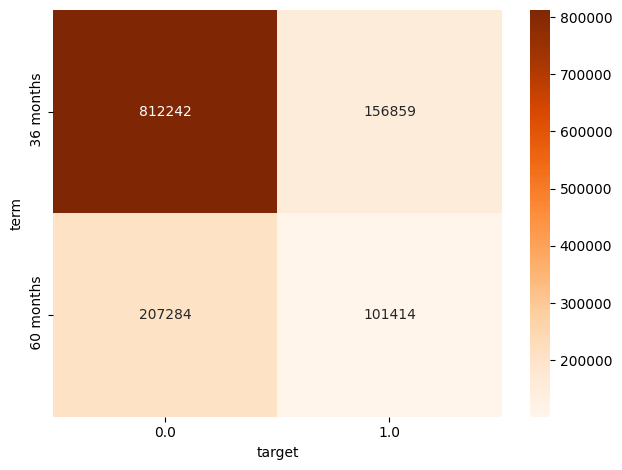

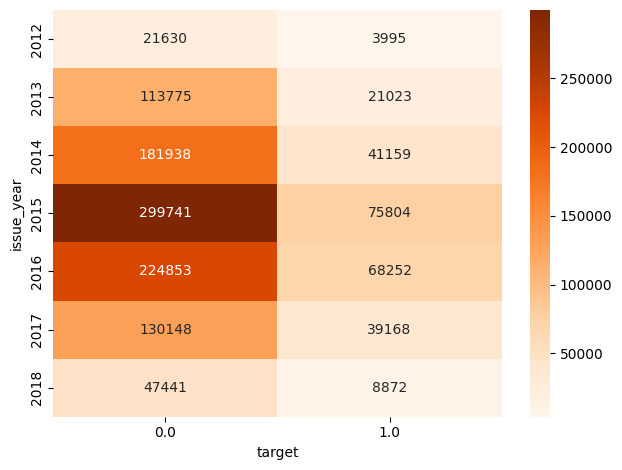

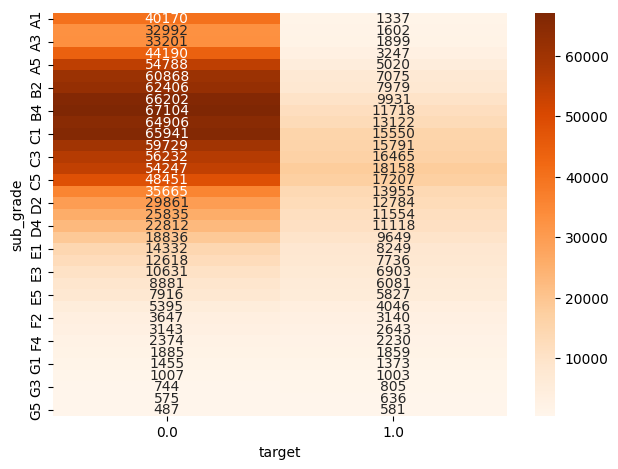

In [12]:
for col in lst:
    sns.heatmap(
        pd.crosstab(df[col], df['target']),
        annot=True,
        fmt='d',
        cmap='Oranges'
    )
    plt.tight_layout()
    plt.show()

C:\Users\gmltk\AppData\Local\Temp\ipykernel_41152\3357883478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


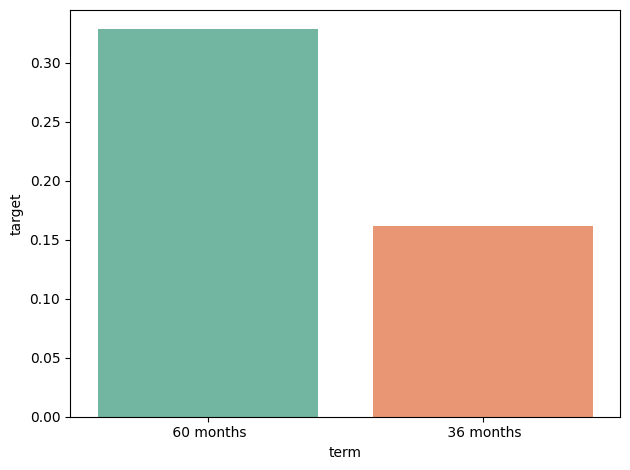

C:\Users\gmltk\AppData\Local\Temp\ipykernel_41152\3357883478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


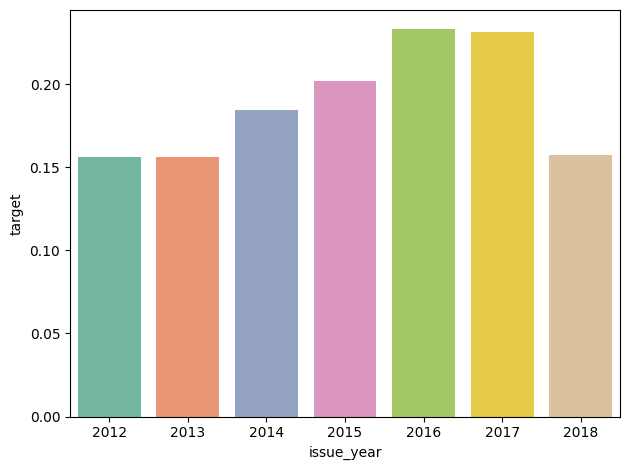

C:\Users\gmltk\AppData\Local\Temp\ipykernel_41152\3357883478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


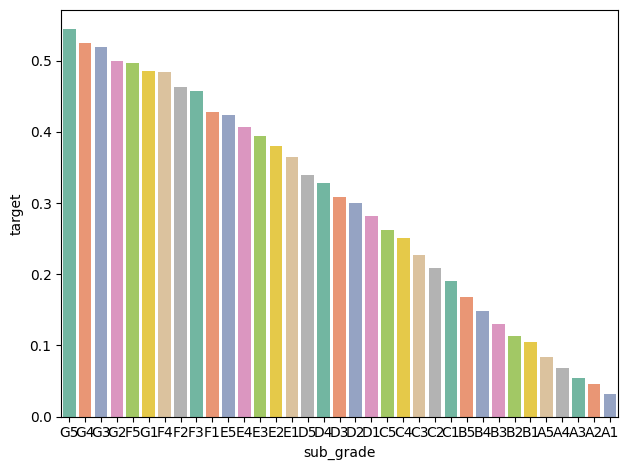

In [15]:
for col in lst:
    mean_target = df.pivot_table(index=col, values='target').sort_values(by='target', ascending=False)
    sns.barplot(
        x=col,
        y='target',
        data=mean_target,
        palette='Set2'
    )
    plt.tight_layout()
    plt.show()

target,0.0,1.0
term,,
36 months,44.373425,-88.162237
60 months,-78.621362,156.206899


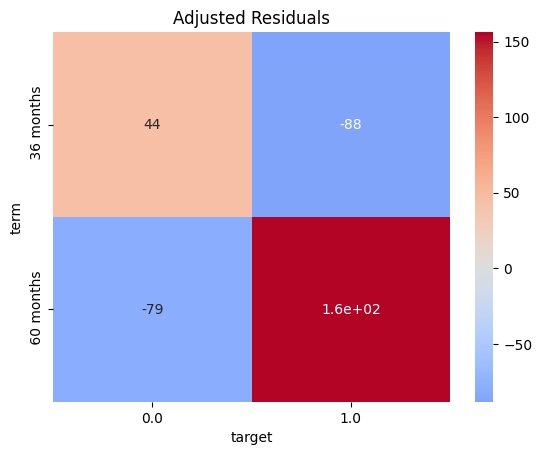

target,0.0,1.0
issue_year,,
2012,8.283282,-16.457433
2013,18.974824,-37.699658
2014,9.324634,-18.526418
2015,0.187086,-0.371706
2016,-18.628577,37.011725
2017,-13.454713,26.732161
2018,11.842167,-23.528316


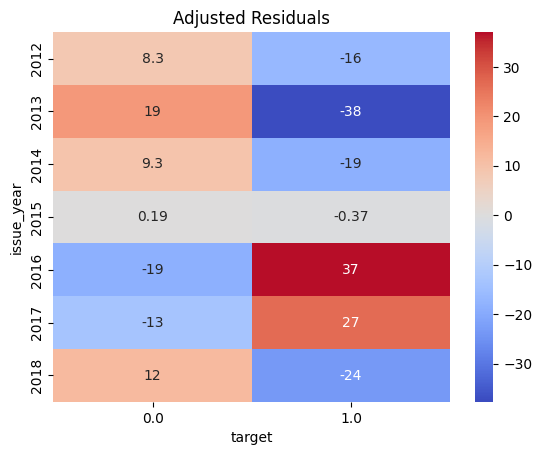

target,0.0,1.0
sub_grade,,
A1,38.754006,-76.997433
A2,32.444495,-64.461539
A3,31.046193,-61.683357
A4,32.594161,-64.758900
A5,32.358280,-64.290245
B1,28.595310,-56.813881
B2,26.363006,-52.378684
B3,22.142160,-43.992601
B4,16.802689,-33.384005


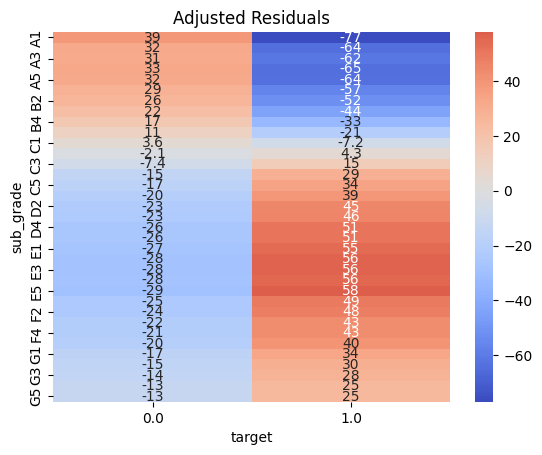

In [22]:

for col in lst:
    # 교차표
    table = pd.crosstab(df[col], df['target']).sort_index(ascending=True)

    # 카이제곱 검정
    chi2, p, dof, expected = stats.chi2_contingency(table)

    expected = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    ).sort_index(ascending=True)
    # 조정된 잔차
    residuals = ((table - expected) / np.sqrt(expected))
    residuals = residuals.sort_index(ascending=True)
    display(residuals)
    
    # 히트맵 시각화
    sns.heatmap(residuals, annot=True, center=0, cmap='coolwarm')
    plt.title("Adjusted Residuals")
    plt.show()